# Analysis companion — filing-tone timestamp audit

This concise notebook generates the evidence and figures used by `paper.qmd` and `slides.qmd`.
The separate paper carries the sustained exposition, literature review, interpretation, and
conclusion. This division of labor illustrates final-project Pathway 2.


In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

EXAMPLE_ROOT = Path("..").resolve()
sys.path.insert(0, str(EXAMPLE_ROOT))
import _pipeline as P

FIG = EXAMPLE_ROOT / "figures"
FIG.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
GREEN, RED, GREY, BLUE = "#2e7d32", "#c62828", "#888888", "#1565c0"


## Data and text readers

Generate the seeded known-truth filings, then score each document with the shallow lexicon and
the richer candidate reader. The printed backend prevents the offline proxy from being mistaken
for an executed transformer.


In [2]:
d = P.make_filings(n=1200)
lexicon = P.lexicon_score(d["text"])
candidate, backend = P.finbert_score(d["text"])
candidate_label = "FinBERT" if backend.startswith("FinBERT") else "richer reader proxy"
print(f"records: {len(d['text']):,}")
print(f"sentiment backend: {backend}")


records: 1,200
sentiment backend: lexicon stand-in (install transformers+torch for real FinBERT)


## Timestamp diagnostic

The inadmissible label includes the announcement response. The admissible label begins after the
filing is public. This cell changes the outcome clock while holding the text score fixed.


period-end label IC: +0.548
filing-date label IC: +0.106


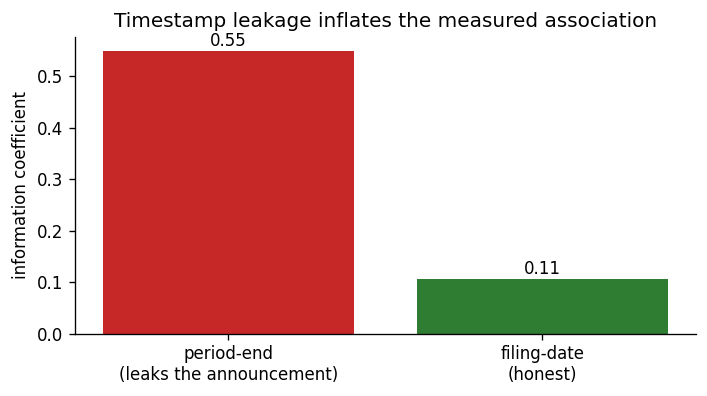

In [3]:
leaked = d["announcement"] + d["drift"]
correct = d["drift"]
ic_leak = P.rank_ic(candidate, leaked)
ic_true = P.rank_ic(candidate, correct)
print(f"period-end label IC: {ic_leak:+.3f}")
print(f"filing-date label IC: {ic_true:+.3f}")

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.bar(["period-end\n(leaks the announcement)", "filing-date\n(honest)"], [ic_leak, ic_true],
       color=[RED, GREEN])
ax.set_ylabel("information coefficient")
ax.set_title("Timestamp leakage inflates the measured association")
for i, value in enumerate([ic_leak, ic_true]):
    ax.text(i, value + 0.01, f"{value:.2f}", ha="center")
fig.tight_layout()
fig.savefig(FIG / "01_leakage.png", bbox_inches="tight")
plt.show()


## Later-sample model comparison

The final 30 percent of records supplies the later comparison. The secondary decision ledger is
a top-minus-bottom tercile spread after 10 basis points of cost on each leg.


reader                  test IC   net tercile spread
richer reader proxy      +0.140              +0.0022
lexicon baseline         +0.136              +0.0014


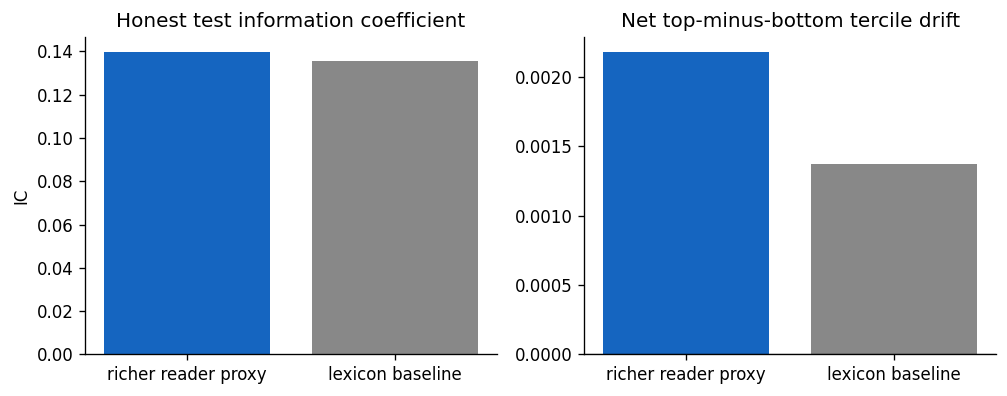

In [4]:
def tercile_spread(score, outcome, cost_bps=10.0):
    high, low = np.quantile(score, 2 / 3), np.quantile(score, 1 / 3)
    gross = outcome[score >= high].mean() - outcome[score <= low].mean()
    return gross - 2 * cost_bps / 1e4

n = len(correct)
test = slice(int(0.7 * n), n)
rows = []
for name, score in [(candidate_label, candidate), ("lexicon baseline", lexicon)]:
    rows.append((name, P.rank_ic(score[test], correct[test]),
                 tercile_spread(score[test], correct[test])))

print(f"{'reader':22} {'test IC':>8} {'net tercile spread':>20}")
for name, ic, spread in rows:
    print(f"{name:22} {ic:>+8.3f} {spread:>+20.4f}")

fig, ax = plt.subplots(1, 2, figsize=(8.5, 3.4))
labels = [row[0] for row in rows]
ax[0].bar(labels, [row[1] for row in rows], color=[BLUE, GREY])
ax[0].set_title("Honest test information coefficient")
ax[0].set_ylabel("IC")
ax[1].bar(labels, [row[2] for row in rows], color=[BLUE, GREY])
ax[1].set_title("Net top-minus-bottom tercile drift")
ax[1].axhline(0, color="black", linewidth=0.7)
fig.tight_layout()
fig.savefig(FIG / "02_finbert_vs_lexicon.png", bbox_inches="tight")
plt.show()


## Reproducibility note

The shared `../_pipeline.py` fixes seed `20260718`. This notebook generates every numerical result
and figure used in the separate paper. Interpretation and literature synthesis remain in
`paper.qmd`, which is the defining separation in Pathway 2.
